# Base Census Deep Learning

In [1]:
import pickle
# read =rb 
with open('../2-3-Classificacao/census_aula.pkl', 'rb') as f:
  X_census_treinamento, y_census_treinamento, X_census_teste, y_census_teste = pickle.load(f)

In [2]:
X_census_treinamento.shape, y_census_treinamento.shape

((27676, 108), (27676,))

In [7]:
X_census_treinamento[:2]

array([[-0.2444502 , -0.17429511, -0.26209736, -0.01466381, -1.5167923 ,
        -0.18838933,  3.43718582, -0.20376145, -0.02073999, -0.17175325,
        -0.19348662, -0.11609195, -0.07201601, -0.10164955, -0.1422718 ,
        -0.12664495, -0.18406376, -0.21053433, -0.44365705, -0.11334387,
         1.44939722, -0.23637391, -0.03960742, -0.13419553, -0.53714425,
        -0.39750806, -0.02658695,  1.08361066, -0.11403678, -0.69878376,
        -0.1802846 , -0.17735813, -0.24494366, -0.36186143, -0.01662771,
        -0.37949517,  2.64728466, -0.17745022, -0.20957797, -0.25595432,
        -0.33554133, -0.06780164, -0.38166338, -0.14260848, -0.35531609,
        -0.17127887, -0.22710355,  1.21163164, -0.58514059, -0.17624972,
        -0.42934582, -0.34403232, -0.22492681, -0.09820087, -0.18155194,
        -0.32576824, -0.09161163,  0.4130197 , -0.70307135,  0.70307135,
        -0.13502327, -0.02416321, -0.06107342, -0.0480488 , -0.04260602,
        -0.05409379, -0.04641598, -0.02933708, -0.0

In [8]:
y_census_treinamento[:2]

array([' <=50K', ' <=50K'], dtype=object)

In [9]:
X_census_teste.shape, y_census_teste.shape

((4885, 108), (4885,))

MLPClassifier

Multi-layer Perceptron classifier.

https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html

- max_iterint 1000 épocas

max_iterint, default=200
Maximum number of iterations. The solver iterates until convergence (determined by ‘tol’) or this number of iterations. For stochastic solvers (‘sgd’, ‘adam’), note that this determines the number of epochs (how many times each data point will be used), not the number of gradient steps.


- verbosebool, default=False

Whether to print progress messages to stdout.

- tolfloat, default=1e-4
 
Tolerance for the optimization. When the loss or score is not improving by at least tol for n_iter_no_change consecutive iterations, unless learning_rate is set to ‘adaptive’, convergence is considered to be reached and training stops.

percorrer mais épocas


- hidden_layer_sizesarray-like of shape(n_layers - 2,), default=(100,)

The ith element represents the number of neurons in the ith hidden layer.

(entrada + saída  )/2

55, duas camadas ocultas criadas

- learning_rate{‘constant’, ‘invscaling’, ‘adaptive’}, default=’constant’

Learning rate schedule for weight updates.

‘constant’ is a constant learning rate given by ‘learning_rate_init’.

‘invscaling’ gradually decreases the learning rate at each time step ‘t’ using an inverse scaling exponent of ‘power_t’. effective_learning_rate = learning_rate_init / pow(t, power_t)

‘adaptive’ keeps the learning rate constant to ‘learning_rate_init’ as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if ‘early_stopping’ is on, the current learning rate is divided by 5.

Only used when solver='sgd'.


taxa de aprendizagem, ajuste dos pesos. 

In [10]:
# (entrada + saída  )/2     108 neurônios de entrada e 1 saída de neurônio
(108 + 1) / 2

54.5

In [12]:
from sklearn.neural_network import MLPClassifier

In [13]:
# 108 neurônios na camada de entrada -> 55  neurônio primeira camada oculta -> 55 segunda camada de oculta -> 1 neurônio na camada de saída
rede_neural_census = MLPClassifier(verbose=True, max_iter = 1000, tol=0.000010,
                                  hidden_layer_sizes = (55,55))
rede_neural_census.fit(X_census_treinamento, y_census_treinamento)

Iteration 1, loss = 0.38902176
Iteration 2, loss = 0.32748548
Iteration 3, loss = 0.31581679
Iteration 4, loss = 0.30797887
Iteration 5, loss = 0.30254393
Iteration 6, loss = 0.29865723
Iteration 7, loss = 0.29533300
Iteration 8, loss = 0.29263700
Iteration 9, loss = 0.29065900
Iteration 10, loss = 0.28728127
Iteration 11, loss = 0.28552808
Iteration 12, loss = 0.28357683
Iteration 13, loss = 0.28189232
Iteration 14, loss = 0.27974117
Iteration 15, loss = 0.27814356
Iteration 16, loss = 0.27659468
Iteration 17, loss = 0.27590762
Iteration 18, loss = 0.27325384
Iteration 19, loss = 0.27147605
Iteration 20, loss = 0.27053792
Iteration 21, loss = 0.26919340
Iteration 22, loss = 0.26720062
Iteration 23, loss = 0.26595460
Iteration 24, loss = 0.26449627
Iteration 25, loss = 0.26403403
Iteration 26, loss = 0.26198278
Iteration 27, loss = 0.25996833
Iteration 28, loss = 0.26024038
Iteration 29, loss = 0.25814115
Iteration 30, loss = 0.25619584
Iteration 31, loss = 0.25656371
Iteration 32, los

MLPClassifier(hidden_layer_sizes=(55, 55), max_iter=1000, tol=1e-05,
              verbose=True)

In [14]:
rede_neural_census.get_params()

{'activation': 'relu',
 'alpha': 0.0001,
 'batch_size': 'auto',
 'beta_1': 0.9,
 'beta_2': 0.999,
 'early_stopping': False,
 'epsilon': 1e-08,
 'hidden_layer_sizes': (55, 55),
 'learning_rate': 'constant',
 'learning_rate_init': 0.001,
 'max_fun': 15000,
 'max_iter': 1000,
 'momentum': 0.9,
 'n_iter_no_change': 10,
 'nesterovs_momentum': True,
 'power_t': 0.5,
 'random_state': None,
 'shuffle': True,
 'solver': 'adam',
 'tol': 1e-05,
 'validation_fraction': 0.1,
 'verbose': True,
 'warm_start': False}

In [15]:
# tolerância => tol=0.000010 ou seja não houve grande alteração com variação do tol nas últimas 10 interation ou épocas.
#Por isso o processo parou

a ideia é dimiunuir o número de iteração 313 épocas de iteração

previsões

In [18]:
previsoes = rede_neural_census.predict(X_census_teste)
previsoes[:100] # submeter a rede neural

array([' <=50K', ' <=50K', ' <=50K', ' >50K', ' <=50K', ' <=50K',
       ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K',
       ' >50K', ' <=50K', ' <=50K', ' <=50K', ' >50K', ' >50K', ' <=50K',
       ' <=50K', ' <=50K', ' >50K', ' >50K', ' <=50K', ' >50K', ' >50K',
       ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K',
       ' <=50K', ' <=50K', ' >50K', ' <=50K', ' <=50K', ' <=50K',
       ' <=50K', ' <=50K', ' <=50K', ' >50K', ' >50K', ' <=50K', ' <=50K',
       ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K',
       ' <=50K', ' >50K', ' <=50K', ' >50K', ' <=50K', ' >50K', ' <=50K',
       ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K',
       ' <=50K', ' <=50K', ' >50K', ' <=50K', ' <=50K', ' <=50K',
       ' <=50K', ' >50K', ' >50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K',
       ' >50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' >50K', ' <=50K',
       ' >50K', ' <=50K', ' >50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K',
       ' <=50

In [19]:
y_census_teste[:100] # compara

array([' <=50K', ' <=50K', ' <=50K', ' <=50K', ' >50K', ' <=50K',
       ' <=50K', ' <=50K', ' >50K', ' <=50K', ' <=50K', ' <=50K', ' >50K',
       ' <=50K', ' <=50K', ' >50K', ' <=50K', ' <=50K', ' <=50K',
       ' <=50K', ' <=50K', ' >50K', ' >50K', ' <=50K', ' <=50K', ' >50K',
       ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K',
       ' <=50K', ' <=50K', ' >50K', ' <=50K', ' >50K', ' <=50K', ' <=50K',
       ' >50K', ' >50K', ' >50K', ' >50K', ' <=50K', ' <=50K', ' <=50K',
       ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K',
       ' >50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K',
       ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K',
       ' <=50K', ' <=50K', ' >50K', ' <=50K', ' >50K', ' <=50K', ' <=50K',
       ' <=50K', ' >50K', ' <=50K', ' <=50K', ' <=50K', ' >50K', ' <=50K',
       ' <=50K', ' >50K', ' >50K', ' <=50K', ' >50K', ' <=50K', ' >50K',
       ' <=50K', ' >50K', ' <=50K', ' >50K', ' <=50K', ' <=50K', ' >50K',
       

In [21]:
from sklearn.metrics import accuracy_score, classification_report


acuracia = accuracy_score(y_census_teste, previsoes)

print('A acurácia do modelo é de {:.2f}%'.format(acuracia*100))

A acurácia do modelo é de 81.56%


0.8155578300921187

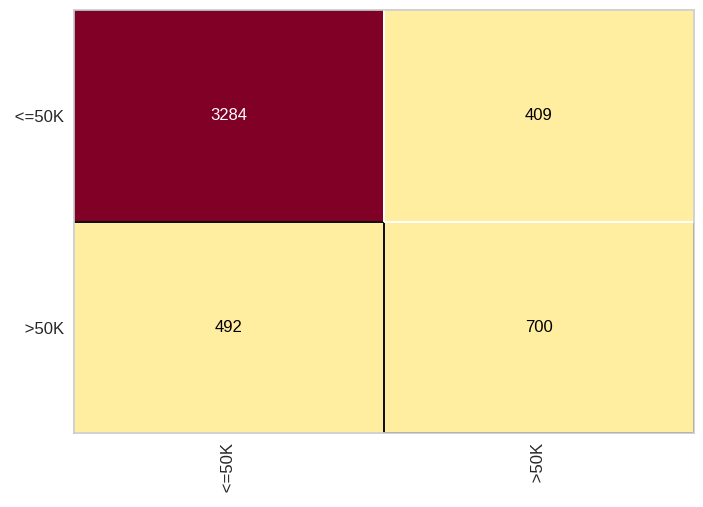

In [22]:
from yellowbrick.classifier import ConfusionMatrix
cm = ConfusionMatrix(rede_neural_census)
cm.fit(X_census_treinamento, y_census_treinamento)
cm.score(X_census_teste, y_census_teste)

In [23]:
print(classification_report(y_census_teste, previsoes))

              precision    recall  f1-score   support

       <=50K       0.87      0.89      0.88      3693
        >50K       0.63      0.59      0.61      1192

    accuracy                           0.82      4885
   macro avg       0.75      0.74      0.74      4885
weighted avg       0.81      0.82      0.81      4885



In [28]:
# acurácia do modelo

# a acurácia, lembrando que no 2-Naive_Bayes_Bayesiano.ipynb, método bayesiano a acurácia era de apenas 47,68% no census
# a acurácia, lembrando que no 3-3_Arvore_decision_Census_parte4.ipynb, método da árvore de decisão simples a acurácia era de 81,04% no census
# a acurácia, lembrando que no 3-5_Arvore_decision_Random_Forest_Census.ipynb método das múltiplas árvores
# => A acurácia do modelo é de 85.08% para 100 árvores (n_estimators).


# a acurácia, lembrando que no 4-4_InducaodeRegras_BaseCEnsus.ipynb, método das regras => Acurácia do modelo 75.92 %

# Acurácia da instância KNN 82.23 % com 5 vizinhos próximos
# Acurácia da instância KNN 82.91 % ideal 10 vizinhos próximos, 5-2AprendizagemKNN_BaseCensus.ipynb

#Acurácia da Regressão Logística 84.97 %, 6-3RegressaoLogistica_BaseCensus.ipynb

#Acurácia da SVM - Support Vector Machine 85.08 %, para Kernel: linear e C: 1.0 , 7-2_SVM_Supporte_Vector_Machine_Base_census.ipynb


#A acurácia deep learning é de 81.56%, hidden_layer_sizes = (55,55))

In [29]:

#naive bayes - tabela de probabilidade

#árvore de decisão - estrutura de dados

#regras - gera regras e classificar

#instância Knn- vizinhos mais próximos, e calcula as distâncias (armazena os dados)

#regressão logistica - melhor curva possível para classificar os registros 

#algoritmo SVM - encontrar uma linha com a margem máxima

#redes neurais - deep learning

precision, 

recall consegue identificar como 89%, como precisão de 87% no <=50K

recall consegue identificar apenas 59%, como precisão de 63% no >50K


## RandomizedSearchCV  -> validação cruzada

In [33]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

#train_test_split(X, y, test_size=0.2, random_state=42)

# Modelo base
rede_neural_model = MLPClassifier(
    max_iter=1500,
    verbose=True,
    tol=0.00001,
    solver='adam',
    activation='relu',
    hidden_layer_sizes=(50, 50)
)

# Espaço de busca dos hiperparâmetros
param_dist = {
    'hidden_layer_sizes': [(50, 50), (100,), (100, 50)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'sgd'],
    'alpha': [0.0001, 0.001, 0.01],  # regularização L2
    'learning_rate': ['constant', 'adaptive']
}

# RandomizedSearch com validação cruzada (cv=5 significa 5-fold CV)
random_search = RandomizedSearchCV(
    estimator=rede_neural_model,
    param_distributions=param_dist,
    n_iter=10,  # número de combinações aleatórias a testar
    cv=5,       # <- aqui está a validação cruzada
    verbose=2,
    random_state=42,
    n_jobs=-1   # paraleliza se possível
)
#https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html
# Executar o ajuste
random_search.fit(X_census_treinamento, y_census_treinamento)

# Ver os melhores parâmetros encontrados
print("Melhores parâmetros encontrados:", random_search.best_params_)

# Avaliação no conjunto de teste
print("Acurácia no teste:", random_search.score(X_census_teste, y_census_teste))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Iteration 89, loss = 0.19905032
Iteration 90, loss = 0.19718071
Iteration 91, loss = 0.19661079
Iteration 92, loss = 0.19619070
Iteration 93, loss = 0.19497678
Iteration 94, loss = 0.19428568
Iteration 95, loss = 0.19426111
Iteration 96, loss = 0.19330178
Iteration 97, loss = 0.19254350
Iteration 98, loss = 0.19274194
Iteration 99, loss = 0.19197722
Iteration 100, loss = 0.19313080
Iteration 101, loss = 0.19107194
Iteration 102, loss = 0.18955886
Iteration 103, loss = 0.18967583
Iteration 104, loss = 0.18901154
Iteration 105, loss = 0.18923135
Iteration 106, loss = 0.18819861
Iteration 107, loss = 0.18784889
Iteration 108, loss = 0.18767664
Iteration 109, loss = 0.18656162
Iteration 110, loss = 0.18697755
Iteration 111, loss = 0.18575969
Iteration 112, loss = 0.18546155
Iteration 113, loss = 0.18689389
Iteration 114, loss = 0.18371592
Iteration 115, loss = 0.18441262
Iteration 116, loss = 0.18451063
Iteration 117, loss = 0.18

random_stateint, RandomState instance or None, default=None
Pseudo random number generator state used for random uniform sampling from lists of possible values instead of scipy.stats distributions. Pass an int for reproducible output across multiple function calls. See Glossary.

In [34]:
# Ver os melhores parâmetros encontrados
print("Melhores parâmetros encontrados:", random_search.best_params_)


Melhores parâmetros encontrados: {'solver': 'adam', 'learning_rate': 'constant', 'hidden_layer_sizes': (100,), 'alpha': 0.01, 'activation': 'relu'}


In [39]:
print("Melhores parâmetros encontrados:", random_search.best_params_)


Melhores parâmetros encontrados: {'solver': 'adam', 'learning_rate': 'constant', 'hidden_layer_sizes': (100,), 'alpha': 0.01, 'activation': 'relu'}


In [40]:
parametros = dict(random_search.best_params_)

In [41]:
parametros

{'solver': 'adam',
 'learning_rate': 'constant',
 'hidden_layer_sizes': (100,),
 'alpha': 0.01,
 'activation': 'relu'}

In [42]:
rede_neural = MLPClassifier(verbose=True, max_iter = 1500, tol=parametros['alpha'],
                                  hidden_layer_sizes = parametros['hidden_layer_sizes'], solver=parametros['solver'],
    activation=parametros['activation'])
rede_neural.fit(X_census_treinamento, y_census_treinamento)

Iteration 1, loss = 0.37812396
Iteration 2, loss = 0.32348608
Iteration 3, loss = 0.31380670
Iteration 4, loss = 0.30784582
Iteration 5, loss = 0.30339222
Iteration 6, loss = 0.29991904
Iteration 7, loss = 0.29716006
Iteration 8, loss = 0.29477378
Iteration 9, loss = 0.29221357
Iteration 10, loss = 0.29027102
Iteration 11, loss = 0.28903923
Iteration 12, loss = 0.28691952
Iteration 13, loss = 0.28557256
Training loss did not improve more than tol=0.010000 for 10 consecutive epochs. Stopping.


MLPClassifier(max_iter=1500, tol=0.01, verbose=True)

In [43]:
previsoes = rede_neural.predict(X_census_teste)
previsoes[:100] # submeter a rede neural

array([' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K',
       ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K',
       ' >50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' >50K', ' <=50K',
       ' <=50K', ' <=50K', ' >50K', ' >50K', ' <=50K', ' >50K', ' >50K',
       ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K',
       ' <=50K', ' <=50K', ' >50K', ' <=50K', ' <=50K', ' <=50K',
       ' <=50K', ' >50K', ' <=50K', ' >50K', ' >50K', ' <=50K', ' <=50K',
       ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K',
       ' <=50K', ' >50K', ' <=50K', ' >50K', ' <=50K', ' <=50K', ' <=50K',
       ' <=50K', ' <=50K', ' >50K', ' <=50K', ' <=50K', ' <=50K',
       ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' >50K', ' <=50K',
       ' <=50K', ' >50K', ' >50K', ' <=50K', ' <=50K', ' <=50K', ' >50K',
       ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K',
       ' <=50K', ' >50K', ' <=50K', ' >50K', ' <=50K', ' <=50K', ' <=50K',
       ' <=50K', ' >5

In [44]:
from sklearn.metrics import accuracy_score, classification_report


acuracia = accuracy_score(y_census_teste, previsoes)

print('A acurácia do modelo é de {:.2f}%'.format(acuracia*100))

A acurácia do modelo é de 84.93%


0.8493346980552713

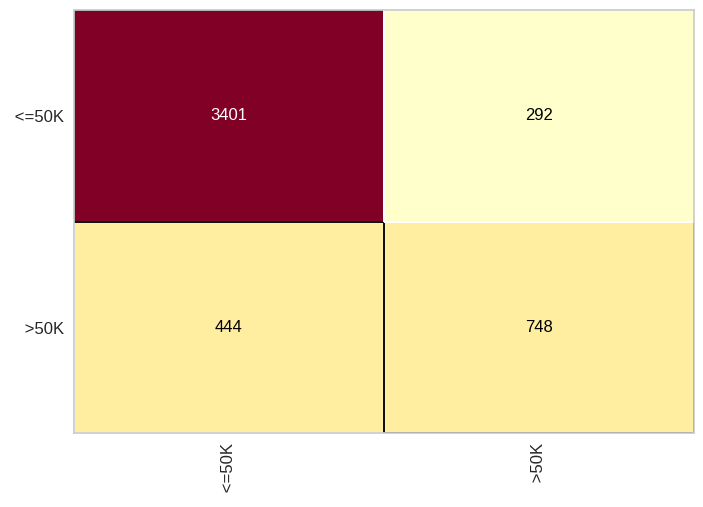

In [46]:
from yellowbrick.classifier import ConfusionMatrix
cm = ConfusionMatrix(rede_neural)
cm.fit(X_census_treinamento, y_census_treinamento)
cm.score(X_census_teste, y_census_teste)

In [47]:
print(classification_report(y_census_teste, previsoes))

              precision    recall  f1-score   support

       <=50K       0.88      0.92      0.90      3693
        >50K       0.72      0.63      0.67      1192

    accuracy                           0.85      4885
   macro avg       0.80      0.77      0.79      4885
weighted avg       0.84      0.85      0.85      4885

